--- Data Snapshot ---
                     Temperature_C
2024-06-15 00:00:00      21.353425
2024-06-15 00:30:00      20.328992
2024-06-15 01:00:00      21.389702
2024-06-15 01:30:00      21.202556
2024-06-15 02:00:00      22.135260 

--- Augmented Dickey-Fuller Test ---
Test Statistic: -2.8352
P-Value: 0.0534
Conclusion: The time series is non-stationary.


--- Extracted Components ---
                        Actual  Underlying_Trend  Seasonality  Noise
2024-06-15 00:00:00  21.353425               NaN    -0.071217    NaN
2024-06-15 00:30:00  20.328992               NaN    -0.115861    NaN
2024-06-15 01:00:00  21.389702               NaN     0.869357    NaN
2024-06-15 01:30:00  21.202556               NaN     0.890147    NaN
2024-06-15 02:00:00  22.135260               NaN     1.716074    NaN 



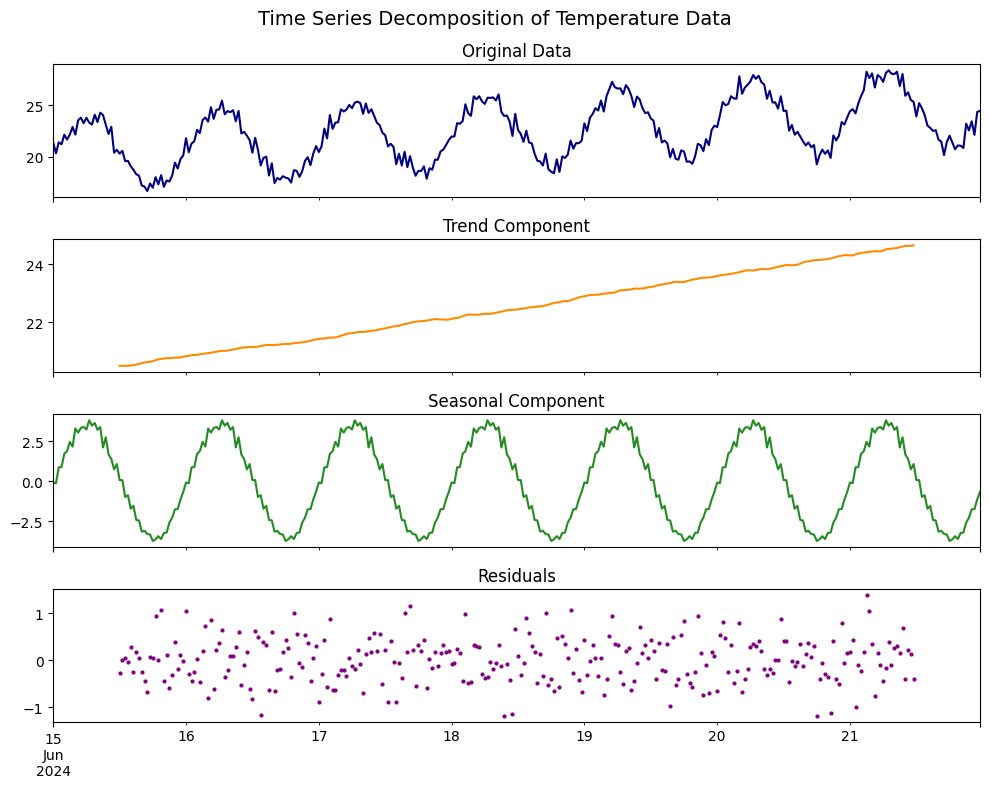

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# 1. Generating synthetic time series data
np.random.seed(101)

# Simulating a week of temperature readings at half-hour intervals
timestamps = pd.date_range(start='2024-06-15', periods=336, freq='30min')

# Creating underlying trend and seasonality
base_trend = np.linspace(20, 25, 336)
seasonality_effect = 3.5 * np.sin(2 * np.pi * timestamps.hour / 24)
random_noise = np.random.normal(loc=0, scale=0.5, size=336)

# Combining components
temperature_readings = base_trend + seasonality_effect + random_noise

# Building the dataframe
temp_df = pd.DataFrame({'Temperature_C': temperature_readings}, index=timestamps)
print("--- Data Snapshot ---")
print(temp_df.head(), "\n")

# 2. Checking for Stationarity
print("--- Augmented Dickey-Fuller Test ---")
adf_result = adfuller(temp_df['Temperature_C'])
print(f"Test Statistic: {adf_result[0]:.4f}")
print(f"P-Value: {adf_result[1]:.4f}")

if adf_result[1] < 0.05:
    print("Conclusion: The time series is stationary.")
else:
    print("Conclusion: The time series is non-stationary.")
print("\n")

# 3. Decomposing the Time Series
ts_decomp = seasonal_decompose(temp_df['Temperature_C'], model='additive', period=48)

# Storing extracted components into a new dataframe
decomp_df = pd.DataFrame({
    'Actual': ts_decomp.observed,
    'Underlying_Trend': ts_decomp.trend,
    'Seasonality': ts_decomp.seasonal,
    'Noise': ts_decomp.resid
})

print("--- Extracted Components ---")
print(decomp_df.head(), "\n")

# 4. Plotting the results
fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
fig.suptitle('Time Series Decomposition of Temperature Data', fontsize=14)

decomp_df['Actual'].plot(ax=axs[0], color='navy', title='Original Data')
decomp_df['Underlying_Trend'].plot(ax=axs[1], color='darkorange', title='Trend Component')
decomp_df['Seasonality'].plot(ax=axs[2], color='forestgreen', title='Seasonal Component')
decomp_df['Noise'].plot(ax=axs[3], color='purple', style='o', markersize=2, title='Residuals')

plt.tight_layout()
plt.show()
